# Modelo CNN

# Importar librerias necesarias

In [96]:
import os
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [97]:
# 1. Instalar la librería (solo la primera vez)
# pip install kagglehub

import kagglehub

# 2. Descarga el dataset (o usa la copia en caché si ya existe)
ruta_base = kagglehub.dataset_download("crowww/a-large-scale-fish-dataset")

print("Dataset descargado en:", ruta_base)

Dataset descargado en: C:\Users\jeffg\.cache\kagglehub\datasets\crowww\a-large-scale-fish-dataset\versions\2


In [98]:
ruta = os.path.join(ruta_base, "Fish_Dataset", "Fish_Dataset")
print(os.listdir(ruta))

['Black Sea Sprat', 'Gilt-Head Bream', 'Hourse Mackerel', 'license.txt', 'README.txt', 'Red Mullet', 'Red Sea Bream', 'Sea Bass', 'Segmentation_example_script.m', 'Shrimp', 'Striped Red Mullet', 'Trout']


## Listas para imagenes y etiquetas para guardar las imagenes y nombre de pez

In [99]:
imagenes = []
etiquetas = []

In [100]:
for especie in os.listdir(ruta):  # el for recorre la lista una por una especie de pez

    carpeta_especie = os.path.join(ruta, especie)   # arma ruta completa hacia la carpeta de la especie

    if os.path.isdir(carpeta_especie):

        # Entrar a la segunda carpeta con el mismo nombre
        carpeta_imagenes = os.path.join(carpeta_especie, especie)   # para que no entre a la carpeta GT que tiene solo siluetas del pez

        if os.path.isdir(carpeta_imagenes):

            for archivo in os.listdir(carpeta_imagenes):    # recorre uno por uno cada archivo de imagen dentro de la carpeta definitiva

                ruta_imagen = os.path.join(carpeta_imagenes, archivo)

                imagen = cv2.imread(ruta_imagen)        # ruta completa, lee el archivo de imagen y lo convierte en array de numeros

                if imagen is not None:  # para precaucion por si hubiera imagenes corruptas

                    imagen = cv2.resize(imagen, (224,224)) # se redimensionan las imagenes porque venian en dimensiones diferentes y se necesitan todas de la misma dimension

                    imagenes.append(imagen)
                    etiquetas.append(especie)   # guarda imagenes y etiquetas en paralelo

## Convertir a numpy

In [101]:
x = np.array(imagenes)
                        # se estructuran los datos
y = np.array(etiquetas)

## Train Test Split

In [102]:
from sklearn.model_selection import train_test_split

In [ ]:
# test_size=0.2 → 80% entrenamiento, 20% prueba.
# random_state=42 → siempre obtendrás la misma división.
# stratify=y → mantiene la misma proporción de especies en entrenamiento y prueba. Esto es
# muy recomendable cuando hay varias clases.

In [103]:
x_train, x_test, y_train, y_test = train_test_split(
    x,      # imagenes
    y,      # etiquetas de especies
    test_size=0.2,      # separa 20% de los datos para test, 80% para entrenamiento
    random_state=42,    # semilla
    stratify=y      #  # mantiene la misma proporción de cada especie en train y test
)

In [104]:
x_train.shape

(7200, 224, 224, 3)

In [106]:
x_test.shape

(1800, 224, 224, 3)

In [107]:
y_train

array(['Hourse Mackerel', 'Gilt-Head Bream', 'Red Sea Bream', ...,
       'Shrimp', 'Shrimp', 'Shrimp'], shape=(7200,), dtype='<U18')

In [109]:
y_test

array(['Red Sea Bream', 'Trout', 'Shrimp', ..., 'Black Sea Sprat',
       'Red Sea Bream', 'Shrimp'], shape=(1800,), dtype='<U18')

In [110]:
print(len(imagenes))

9000


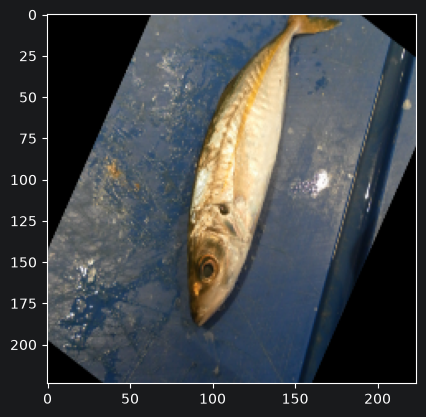

In [112]:
primera_imagen = x_train[0] # toma la primera imagen del set de entrenamiento

plt.imshow(cv2.cvtColor(primera_imagen, cv2.COLOR_BGR2RGB)) # cv2 lee las imágenes en orden BGR (Azul-Verde-Rojo), pero matplotlib espera RGB (Rojo-Verde-Azul)
# si no se hace esta conversión, los colores se ven invertidos (el azul se vería naranja, etc.)
plt.show()  # muestra la imagen en pantalla
plt.show()

In [113]:
primera_imagen.shape

(224, 224, 3)

In [114]:
from collections import Counter

Counter(y)
# cuenta cuántas veces aparece cada especie dentro del array y (etiquetas)
# sirve para verificar el balance de clases: si todas las especies tienen
# aproximadamente la misma cantidad de imágenes, el dataset está balanceado

Counter({np.str_('Black Sea Sprat'): 1000,
         np.str_('Gilt-Head Bream'): 1000,
         np.str_('Hourse Mackerel'): 1000,
         np.str_('Red Mullet'): 1000,
         np.str_('Red Sea Bream'): 1000,
         np.str_('Sea Bass'): 1000,
         np.str_('Shrimp'): 1000,
         np.str_('Striped Red Mullet'): 1000,
         np.str_('Trout'): 1000})

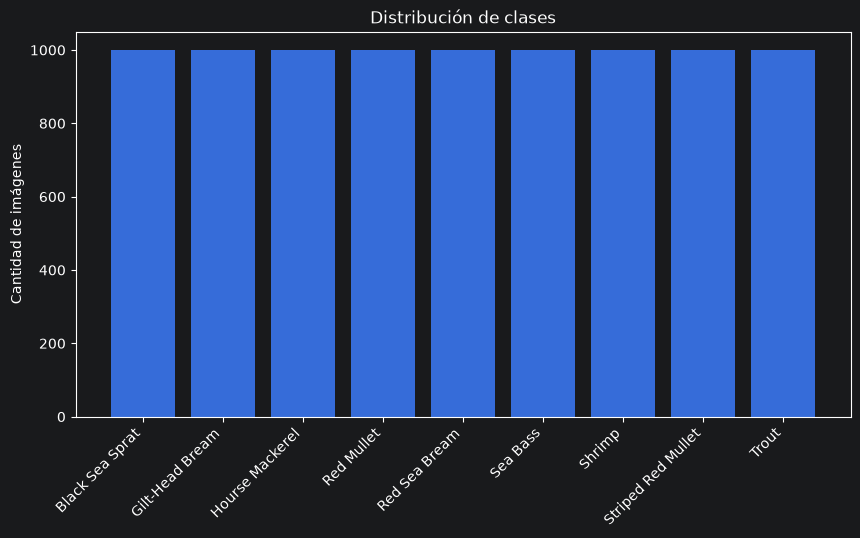

In [115]:
conteo = Counter(y)
plt.figure(figsize=(10,5))
plt.bar(conteo.keys(), conteo.values())
plt.xticks(rotation=45, ha='right')
plt.ylabel("Cantidad de imágenes")
plt.title("Distribución de clases")
plt.show()

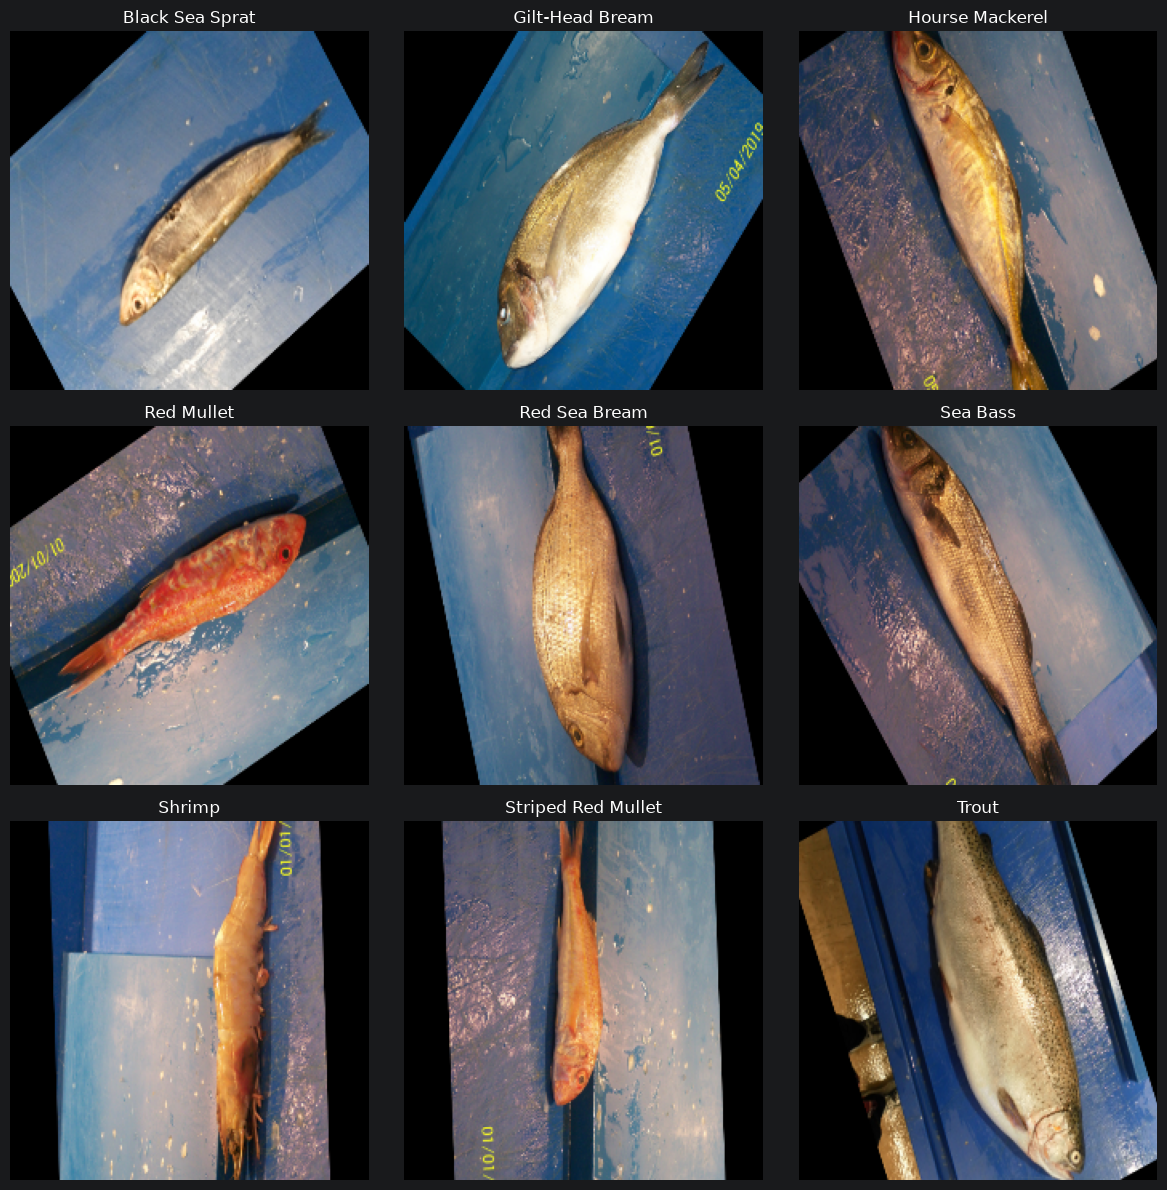

In [116]:
especies = list(conteo.keys())      # lista con el nombre de cada especie única
fig, axes = plt.subplots(3, 3, figsize=(12,12))     # crea una cuadrícula de 3x3
for ax, especie in zip(axes.ravel(), especies):     # recorre cada subgráfico
    idx = etiquetas.index(especie)       # busca la posición (índice) de la primera imagen que pertenece a esa especie
    ax.imshow(cv2.cvtColor(imagenes[idx], cv2.COLOR_BGR2RGB))       # muestra esa imagen en el subgráfico correspondiente (convertida a RGB)
    ax.set_title(especie)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [117]:
primera_imagen = x_train[0]
print(primera_imagen.shape)   # (224, 224, 3)   alto, ancho, canales de color
print(primera_imagen.max(), primera_imagen.min())  # 255, 0 (antes de escalar)
primera_imagen  # muestra el array crudo
# sale array de 0 por los bordes negros de las imagenes

(224, 224, 3)
255 0


array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], shape=(224, 224, 3), dtype=uint8)

In [119]:
print("Valor promedio de la imagen:", primera_imagen.mean())
print("¿Tiene píxeles distintos de cero?", (primera_imagen > 0).any())

# Mira el centro de la imagen, donde debería estar el pez
primera_imagen[100:105, 100:105]

Valor promedio de la imagen: 78.26806308460884
¿Tiene píxeles distintos de cero? True


array([[[139, 197, 233],
        [ 89, 153, 199],
        [105, 175, 223],
        [106, 172, 220],
        [111, 177, 222]],

       [[116, 178, 222],
        [ 92, 156, 203],
        [107, 174, 221],
        [129, 195, 239],
        [139, 204, 246]],

       [[ 92, 155, 204],
        [117, 182, 230],
        [124, 190, 236],
        [158, 220, 253],
        [156, 218, 253]],

       [[ 79, 143, 193],
        [102, 170, 218],
        [115, 180, 224],
        [118, 176, 221],
        [122, 180, 225]],

       [[105, 169, 218],
        [107, 174, 223],
        [104, 166, 216],
        [ 94, 149, 198],
        [ 98, 157, 203]]], dtype=uint8)

## Codificacion de etiquetas

In [120]:
from sklearn.preprocessing import LabelEncoder

In [121]:
encoder = LabelEncoder()
y_train_enc = encoder.fit_transform(y_train) # Convierte cada nombre de especie a un numero
y_test_enc = encoder.transform(y_test)

In [122]:
clases = encoder.classes_ # Nombre de cada especie
clases

array(['Black Sea Sprat', 'Gilt-Head Bream', 'Hourse Mackerel',
       'Red Mullet', 'Red Sea Bream', 'Sea Bass', 'Shrimp',
       'Striped Red Mullet', 'Trout'], dtype='<U18')

In [124]:
n_clases = len(clases) # Numero de especies para las neuronas en la capa final
n_clases

9

## Realizar el one-hot

In [125]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train_enc)
y_test_cat = to_categorical(y_test_enc)

## Manipulacion de imagenes

In [126]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [127]:
image_shape = (224, 224, 3)  # Dimension fija a utilizar

In [128]:
image_gen = ImageDataGenerator(rotation_range=20, # rotación máxima de 20º (depende del caso de uso)
                               width_shift_range=0.10, # Desplazamiento en la anchura máximo del -5% --- +5%
                               height_shift_range=0.10, # Desplazamiento en la altura máximo del -5% --- +5%
                               rescale=1/255, # Reescalar la imagen para normalizarla entre 0-1
                               shear_range=0.1, # Distorsión de la imagen a partir de un eje - persepectiva (max 10%)
                               zoom_range=0.1, # Zoom in máximo 10%
                               horizontal_flip=True, # Permitir giro horizontal de la imagen (espejo)
                               fill_mode='nearest' # Rellenar píxeles vacíos con el valor más cercano
                              )

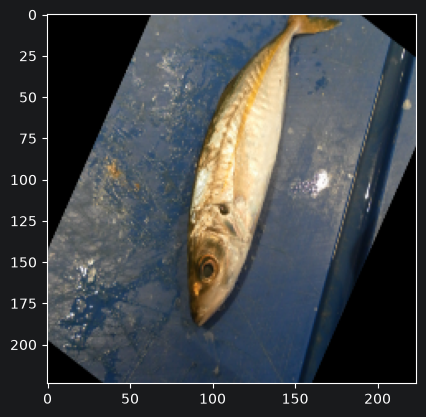

In [129]:
plt.imshow(cv2.cvtColor(x_train[0], cv2.COLOR_BGR2RGB)) # Esta seria la imagen original

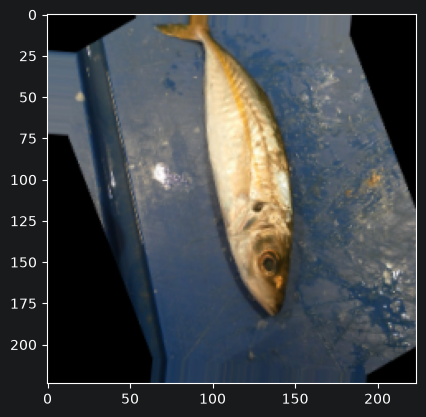

In [130]:
plt.imshow(cv2.cvtColor(image_gen.random_transform(x_train[0]).astype('uint8'), cv2.COLOR_BGR2RGB)) # Misma imagen pero manipulada de manera aleatoria

In [131]:
batch_size = 16 #Definimos un batch_size en función de la RAM

In [132]:
train_image_gen = image_gen.flow(x_train, y_train_cat, batch_size=batch_size)

In [133]:
test_image_gen = image_gen.flow(x_test, y_test_cat, batch_size=batch_size, shuffle=False)
# Sin shuffle para que el orden calce con y_test_enc al evaluar

# Creacion del modelo 

In [134]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense, Conv2D, MaxPooling2D

In [135]:
model = Sequential()

# CAPA CONVOLUCIONAL
model.add(Conv2D(filters=32, kernel_size=(3,3), input_shape=image_shape, activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# CAPA CONVOLUCIONAL (más capas convolucionales conforme mayor complejidad del dataset de imágenes, aumentar progresivamente número de filtros en potencia de 2)
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# CAPA CONVOLUCIONAL (más capas convolucionales conforme mayor complejidad del dataset de imágenes, aumentar progresivamente número de filtros en potencia de 2)
model.add(Conv2D(filters=128, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# CAPA FLATTEN Convierte el mapa de características en un array de 1 dimensión antes de la capa final
model.add(Flatten())

# CAPA DENSE (Indicar neuronas potencia de 2, variable para optimizar modelo)
model.add(Dense(256))
model.add(Activation('relu'))

# CAPA DROPOUT (ayuda a reducir overfitting desactivando aleatoriamente neuronas durante el entrenamiento(epoc))
model.add(Dropout(0.5))

# CAPA FINAL DE CLASIFICACIÓN (Una neurona por especie, softmax porque es multiclase)
model.add(Dense(n_clases, activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [136]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,246,985 (84.87 MB)

 Trainable params: 22,246,985 (84.87 MB)

 Non-trainable params: 0 (0.00 B)

# Entrenamiento del modelo

In [137]:
from tensorflow.keras.callbacks import EarlyStopping

In [138]:
early_stop = EarlyStopping(monitor='val_loss', patience=2)

In [139]:
import warnings
warnings.filterwarnings('ignore')

In [140]:
results = model.fit(train_image_gen,
                     epochs=15,
                     steps_per_epoch=len(x_train)//batch_size,
                     validation_data=test_image_gen,
                     validation_steps=len(x_test)//batch_size,
                     callbacks=[early_stop])

Epoch 1/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 601s 1s/step - accuracy: 0.4236 - loss: 1.5342 - val_accuracy: 0.4542 - val_loss: 1.3528
Epoch 2/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 671s 1s/step - accuracy: 0.6263 - loss: 0.9947 - val_accuracy: 0.8158 - val_loss: 0.5914
Epoch 3/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 710s 2s/step - accuracy: 0.7408 - loss: 0.6987 - val_accuracy: 0.8661 - val_loss: 0.3943
Epoch 4/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 768s 2s/step - accuracy: 0.8082 - loss: 0.5240 - val_accuracy: 0.8895 - val_loss: 0.3397
Epoch 5/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 617s 1s/step - accuracy: 0.8321 - loss: 0.4700 - val_accuracy: 0.8465 - val_loss: 0.3928
Epoch 6/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 670s 1s/step - accuracy: 0.8539 - loss: 0.4158 - val_accuracy: 0.9135 - val_loss: 0.2313
Epoch 7/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 668s 1s/step - accuracy: 0.8778 - loss: 0.3457 - val_accuracy: 0.9448 - val_loss: 0.1434
Epoch 8/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 676s 2s/step - accuracy: 0.8881 - loss: 0.3248 - val_accu

In [141]:
from tensorflow.keras.models import load_model
model.save('modelo_CNN_especies.h5')  # Guarda el modelo

In [142]:
losses = pd.DataFrame(model.history.history)  # loss/accuracy por epoca

<Axes: >

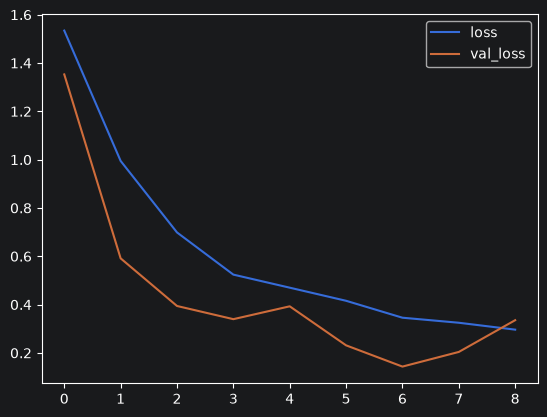

In [143]:
losses[['loss','val_loss']].plot() # Perdida en train vs. test

<Axes: >

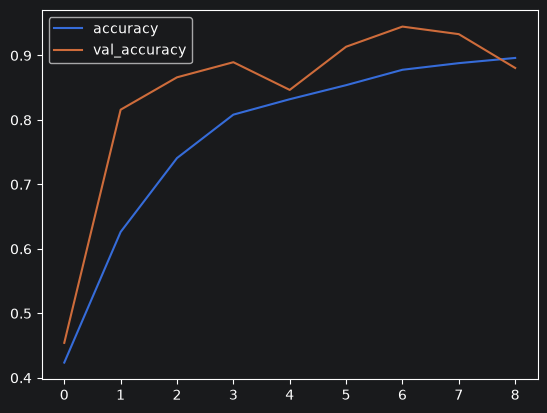

In [144]:
losses[['accuracy','val_accuracy']].plot() # Precisión en train vs. test

# Evaluacion del modelo

## Prediccion sobre el conjunto de test

In [145]:
model.metrics_names # Nombre de las metricas

['loss', 'compile_metrics']

In [146]:
model.evaluate(test_image_gen) # Lost, accuracy, sobre el test

113/113 ━━━━━━━━━━━━━━━━━━━━ 69s 600ms/step - accuracy: 0.8811 - loss: 0.3295


[0.3294781446456909, 0.8811110854148865]

In [147]:
pred_probabilities = model.predict(test_image_gen) # Probabilidad por clase para cada imagen

113/113 ━━━━━━━━━━━━━━━━━━━━ 63s 555ms/step


In [148]:
pred_probabilities

array([[2.10256801e-18, 1.71440151e-02, 1.74097761e-06, ...,
        8.53570483e-14, 5.34873891e-07, 4.30517175e-05],
       [2.51531330e-19, 2.63142429e-04, 3.85757431e-07, ...,
        5.41641096e-20, 9.54283527e-11, 9.90238309e-01],
       [3.09805244e-15, 1.13087626e-13, 2.84626882e-08, ...,
        9.99952435e-01, 4.75575398e-05, 1.42681612e-20],
       ...,
       [9.95953918e-01, 9.39517903e-08, 1.87044451e-03, ...,
        2.40376030e-05, 2.14539119e-03, 2.26971428e-10],
       [4.88616749e-14, 6.92769513e-02, 2.32781604e-04, ...,
        1.26293076e-09, 3.62954997e-05, 1.22370737e-04],
       [2.94679882e-14, 5.48068839e-12, 2.54278154e-10, ...,
        9.99790132e-01, 2.09791222e-04, 1.14040475e-20]],
      shape=(1800, 9), dtype=float32)

In [149]:
# Se queda con la clase de mayor probabilidad
predictions = np.argmax(pred_probabilities, axis=-1)

In [150]:
predictions

array([4, 8, 6, ..., 0, 4, 6], shape=(1800,))

In [151]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

In [152]:
# Genera las predicciones realizadas
print(classification_report(y_test_enc, predictions, target_names=clases))

                    precision    recall  f1-score   support

   Black Sea Sprat       0.94      0.98      0.96       200
   Gilt-Head Bream       0.94      0.58      0.72       200
   Hourse Mackerel       0.86      0.99      0.92       200
        Red Mullet       0.99      1.00      1.00       200
     Red Sea Bream       0.77      0.93      0.84       200
          Sea Bass       0.89      0.70      0.79       200
            Shrimp       0.83      1.00      0.90       200
Striped Red Mullet       0.88      0.78      0.83       200
             Trout       0.90      0.98      0.94       200

          accuracy                           0.88      1800
         macro avg       0.89      0.88      0.88      1800
      weighted avg       0.89      0.88      0.88      1800



In [154]:
confusion_matrix(y_test_enc, predictions)

array([[196,   0,   4,   0,   0,   0,   0,   0,   0],
       [  1, 116,   9,   0,  40,  17,   0,   0,  17],
       [  1,   0, 198,   0,   0,   0,   1,   0,   0],
       [  0,   0,   0, 200,   0,   0,   0,   0,   0],
       [  1,   0,  10,   0, 185,   0,   0,   1,   3],
       [  8,   7,   6,   0,  15, 141,   0,  21,   2],
       [  0,   0,   0,   0,   0,   0, 200,   0,   0],
       [  1,   0,   0,   2,   0,   0,  41, 156,   0],
       [  0,   0,   3,   0,   1,   0,   0,   0, 196]])

<Axes: >

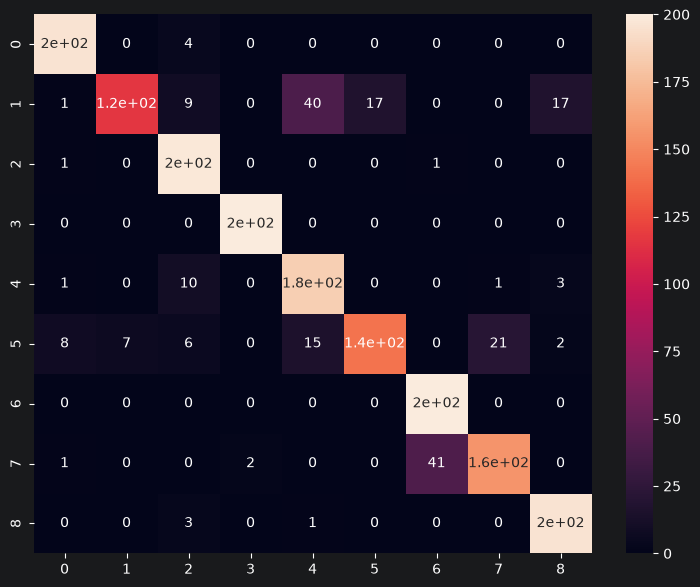

In [155]:
plt.figure(figsize=(9,7))
sns.heatmap(confusion_matrix(y_test_enc, predictions), annot=True)